### Regression
#### regresssion is supervised machine technique that is basically used to predict the continuous numerical values

#### for example :
#### Temp in city      - 30  40  42  20  12  25  25
#### sales of ice cream- 500 700 750 410 250 320 900
 
#### students
#### study hours :  10   8    12   5    15   4    6    8
#### attendance  :  92   85   95   75   89   70   59   78
#### marks scored:  420  410  430  320  435  300  380  405

#### Total 8 rows and 3 cols
#### (input) x-(study hours and attendance)-Features
#### (output)y-(marks)                     -Response on labels

### simple linear regression
in this kind or regression one independent variable predicts the one dependent variable
Marks=m*Hours+b
### Multiple linear regression

marks=c0+c1(hours)+cs(attendance)

In [5]:
import pandas as pd
import numpy as np
import kagglehub

In [3]:
path=kagglehub.dataset_download("lainguyn123/student-performance-factors")

100%|██████████| 93.9k/93.9k [00:00<00:00, 181kB/s]

Extracting files...


In [7]:
df=pd.read_csv(path+"/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
df.shape

(6607, 20)

In [9]:
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [11]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [12]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [13]:
df.dropna(inplace=True)

In [15]:
df.shape

(6378, 20)

In [16]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

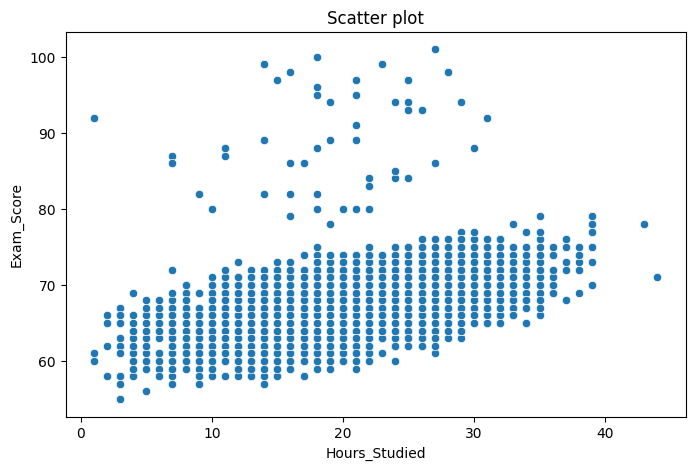

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Hours_Studied",y="Exam_Score",data=df)
plt.title("Scatter plot")
plt.show()

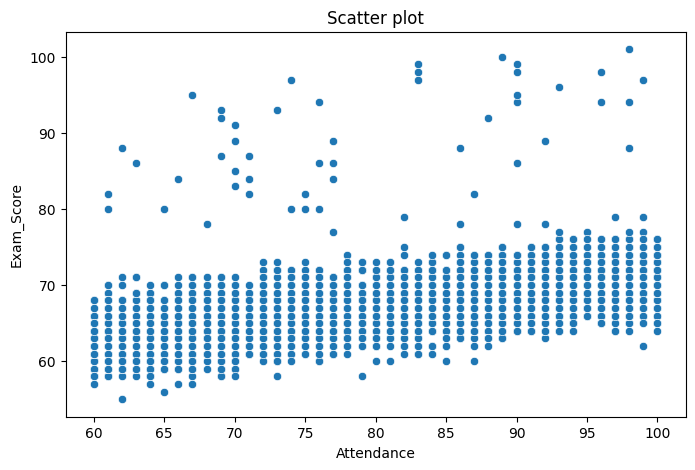

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Attendance",y="Exam_Score",data=df)
plt.title("Scatter plot")
plt.show()

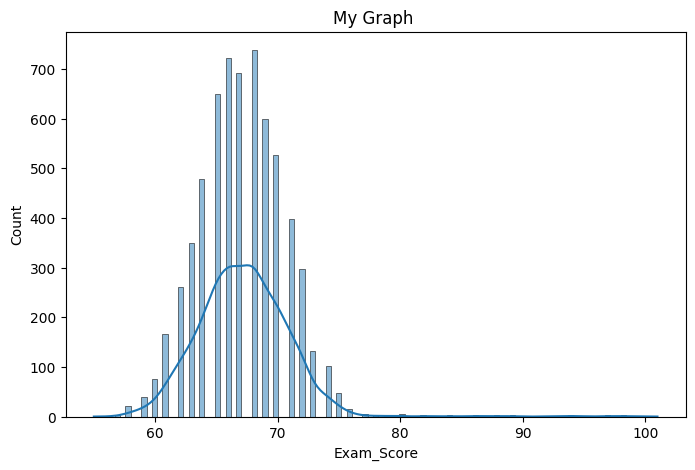

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(df["Exam_Score"],kde=True)
plt.title("My Graph ")
plt.show()

In [25]:
print(df['Exam_Score'].mean())
print(df["Exam_Score"].median())

67.25211665098777
67.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [50]:
x=df[["Hours_Studied","Attendance","Previous_Scores"]]
x

,Hours_Studied,Attendance,Previous_Scores
0,23,84,73
1,19,64,59
2,24,98,91
3,29,89,98
4,19,92,65
...,...,...,...
6602,25,69,76
6603,23,76,81
6604,20,90,65
6605,10,86,91


In [51]:
y=df["Exam_Score"]
y

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: Exam_Score, Length: 6378, dtype: int64

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=60,test_size=.30)


In [54]:
my_model=LinearRegression()
my_model.fit(x_train,y_train)
y_pred=my_model.predict(x_test)
acc=r2_score(y_test,y_pred)
acc*100

50.86782396809406

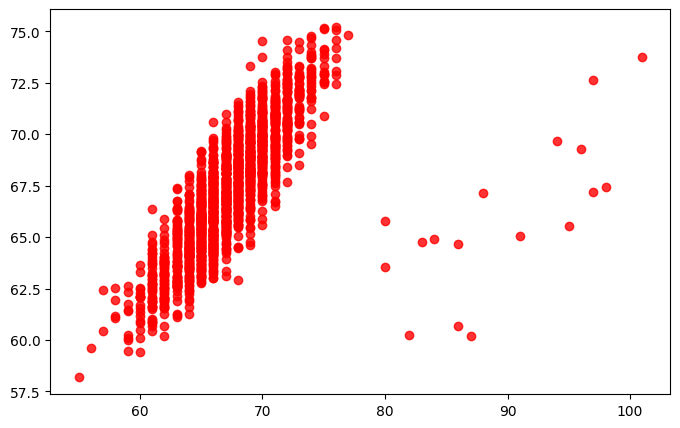

In [55]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred,color="red",alpha=0.8)
plt.show()